In [1]:
from XRD_Classes import XRD_Analyzer, XRD_File
import pathlib

folder = pathlib.Path("/mnt/beam/raw data/XAS/MAX IV Balder 2026 29 01 - 02 02/2026012908/process/azint/")
name = "scan-0775_eiger_xrd_integrated.h5"
XRD = XRD_File(folder / name, 13000) # add energy of XRD in eV

/mnt/beam/raw data/XAS/MAX IV Balder 2026 29 01 - 02 02/2026012908/process/azint/scan-0775_eiger_xrd_integrated.h5


#### baseline Correction and Normalization of intensity

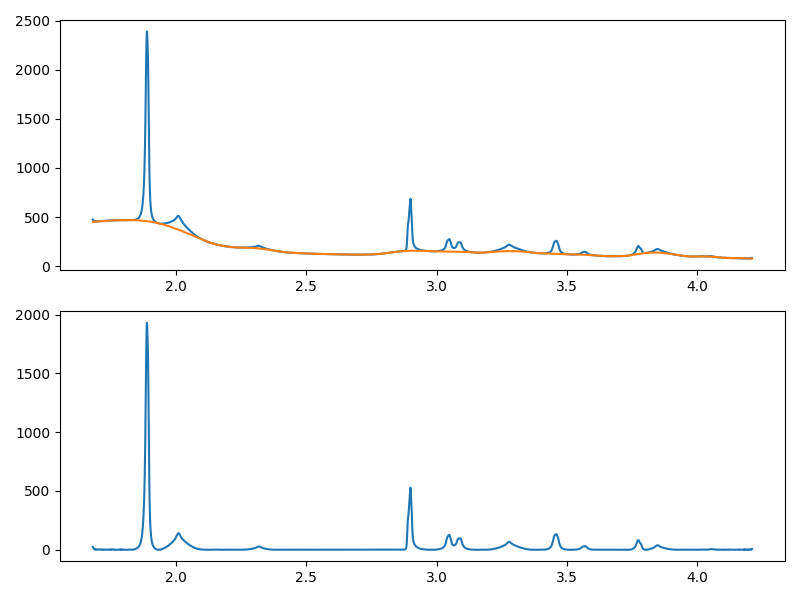

In [8]:
# select baseline treshhold interactivly
%matplotlib widget
XRD.baselineCorrection()

In [2]:
# set known baseline threshhold
XRD.data.baseline_lam=3100

In [3]:
# apply normalization by using maximal Integral of a specific region in q
XRD.normalizeByRegion(lower=1.85, upper=1.93)

In [4]:
XRD.export_processed(pathlib.Path("./test.txt"), in_q=False)

corrected
normalized
successfully written to test.txt


#### display data

corrected
normalized


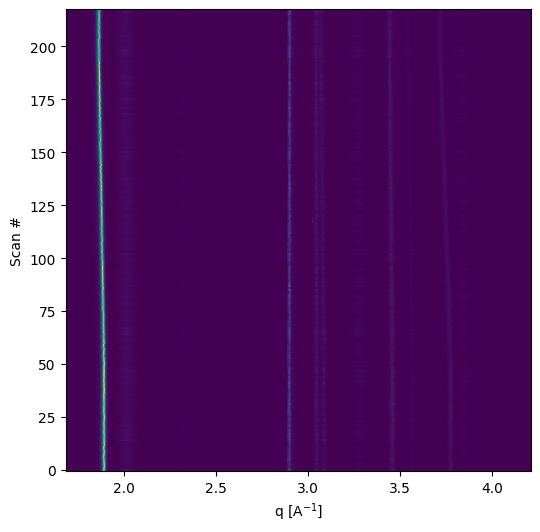

In [4]:
# 2D plot
%matplotlib inline
fig, ax = XRD.plot2D(figsize=(6,6), in_q=True)

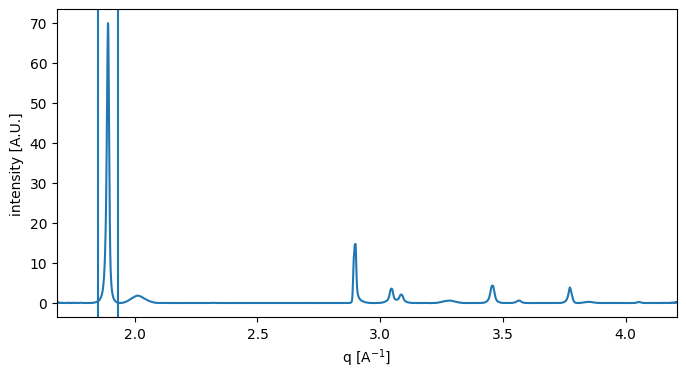

In [ ]:
# plot single Spectra with references
%matplotlib inline
fig, ax = XRD.plot1D(40, figsize=(8,4), in_q=True)

### Experiment section

In [4]:
reflexes = XRD.data.reflexes(13000, snr=20, min_length=20, delta_pos=0.05, height_mlt=.3, default_sigma=0.05)

recalculating reflexes
6 finished
10 finished
5 finished
3 finished
1 finished
9 finished
7 finished
4 finished
11 finished
12 finished
0 finished
8 finished
16 finished
2 finished
17 finished
15 finished
21 finished
23 finished
26 finished
28 finished
29 finished
30 finished
31 finished
18 finished
32 finished
14 finished
25 finished
27 finished
36 finished
35 finished
37 finished
39 finished
19 finished
41 finished
22 finished
43 finished
44 finished
46 finished
42 finished
49 finished
50 finished
51 finished
52 finished
47 finished
53 finished
54 finished
40 finished
58 finished
56 finished
55 finished
60 finished
62 finished
33 finished
59 finished
64 finished
63 finished
66 finished
67 finished
68 finished
57 finished
71 finished
69 finished
70 finished
72 finished
73 finished
75 finished
76 finished
74 finished
78 finished
79 finished
77 finished
24 finished
82 finished
83 finished
81 finished
84 finished
85 finished
87 finished
88 finished
45 finished
80 finished
89 finished
91 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


weights = np.array([1, .1, .1, 0])
threshold = np.exp(-2.5)
print(threshold)


g_min = np.min([arr.min(axis=0) for arr in reflexes], axis=0)
g_max = np.max([arr.max(axis=0) for arr in reflexes], axis=0)
g_min[3] = 0
g_max[3] = 1

scaled_res = [(arr - g_min) / (g_max - g_min) * weights for arr in reflexes]

def initReflex(first_img: int, first_pos: int) -> np.ndarray:
    array = np.full((len(scaled_res)), np.nan)
    array[first_img] = first_pos
    return array

tracked_reflexes: list[np.ndarray]= []
for i in range(len(scaled_res[0])):
    tracked_reflexes.append(initReflex(0, int(i)))

for i in range(len(scaled_res)-1):
    cost_mat = np.sqrt(np.sum(np.square(scaled_res[i][:, np.newaxis, :] - scaled_res[i+1][np.newaxis, :, :]), axis = 2))

    j = 0
    assigned = np.full((cost_mat.shape[1]), False)
    while j < min(cost_mat.shape):
        j += 1
        idx = np.unravel_index(np.argmin(cost_mat), cost_mat.shape)
        cur_val = cost_mat[idx]
        if cur_val > threshold:
            break
        
        a, b = idx
        cost_mat[a,:] = 1
        cost_mat[:,b] = 1

        found_reflex = False
        for r in tracked_reflexes:
            if r[i] == a:
                r[i+1] = b
                assigned[b] = True
                found_reflex = True

        assert found_reflex, f"this should not happen: {i}, {a}, {b}"

    for l in np.where(~assigned)[0]:
        tracked_reflexes.append(initReflex(i+1, l))


import matplotlib.pyplot as plt
plt.subplots(figsize=(12,4))
for r in tracked_reflexes:
    plt.plot(np.arange(len(scaled_res)), r)    



0.0820849986238988


NameError: name 'reflexes' is not defined

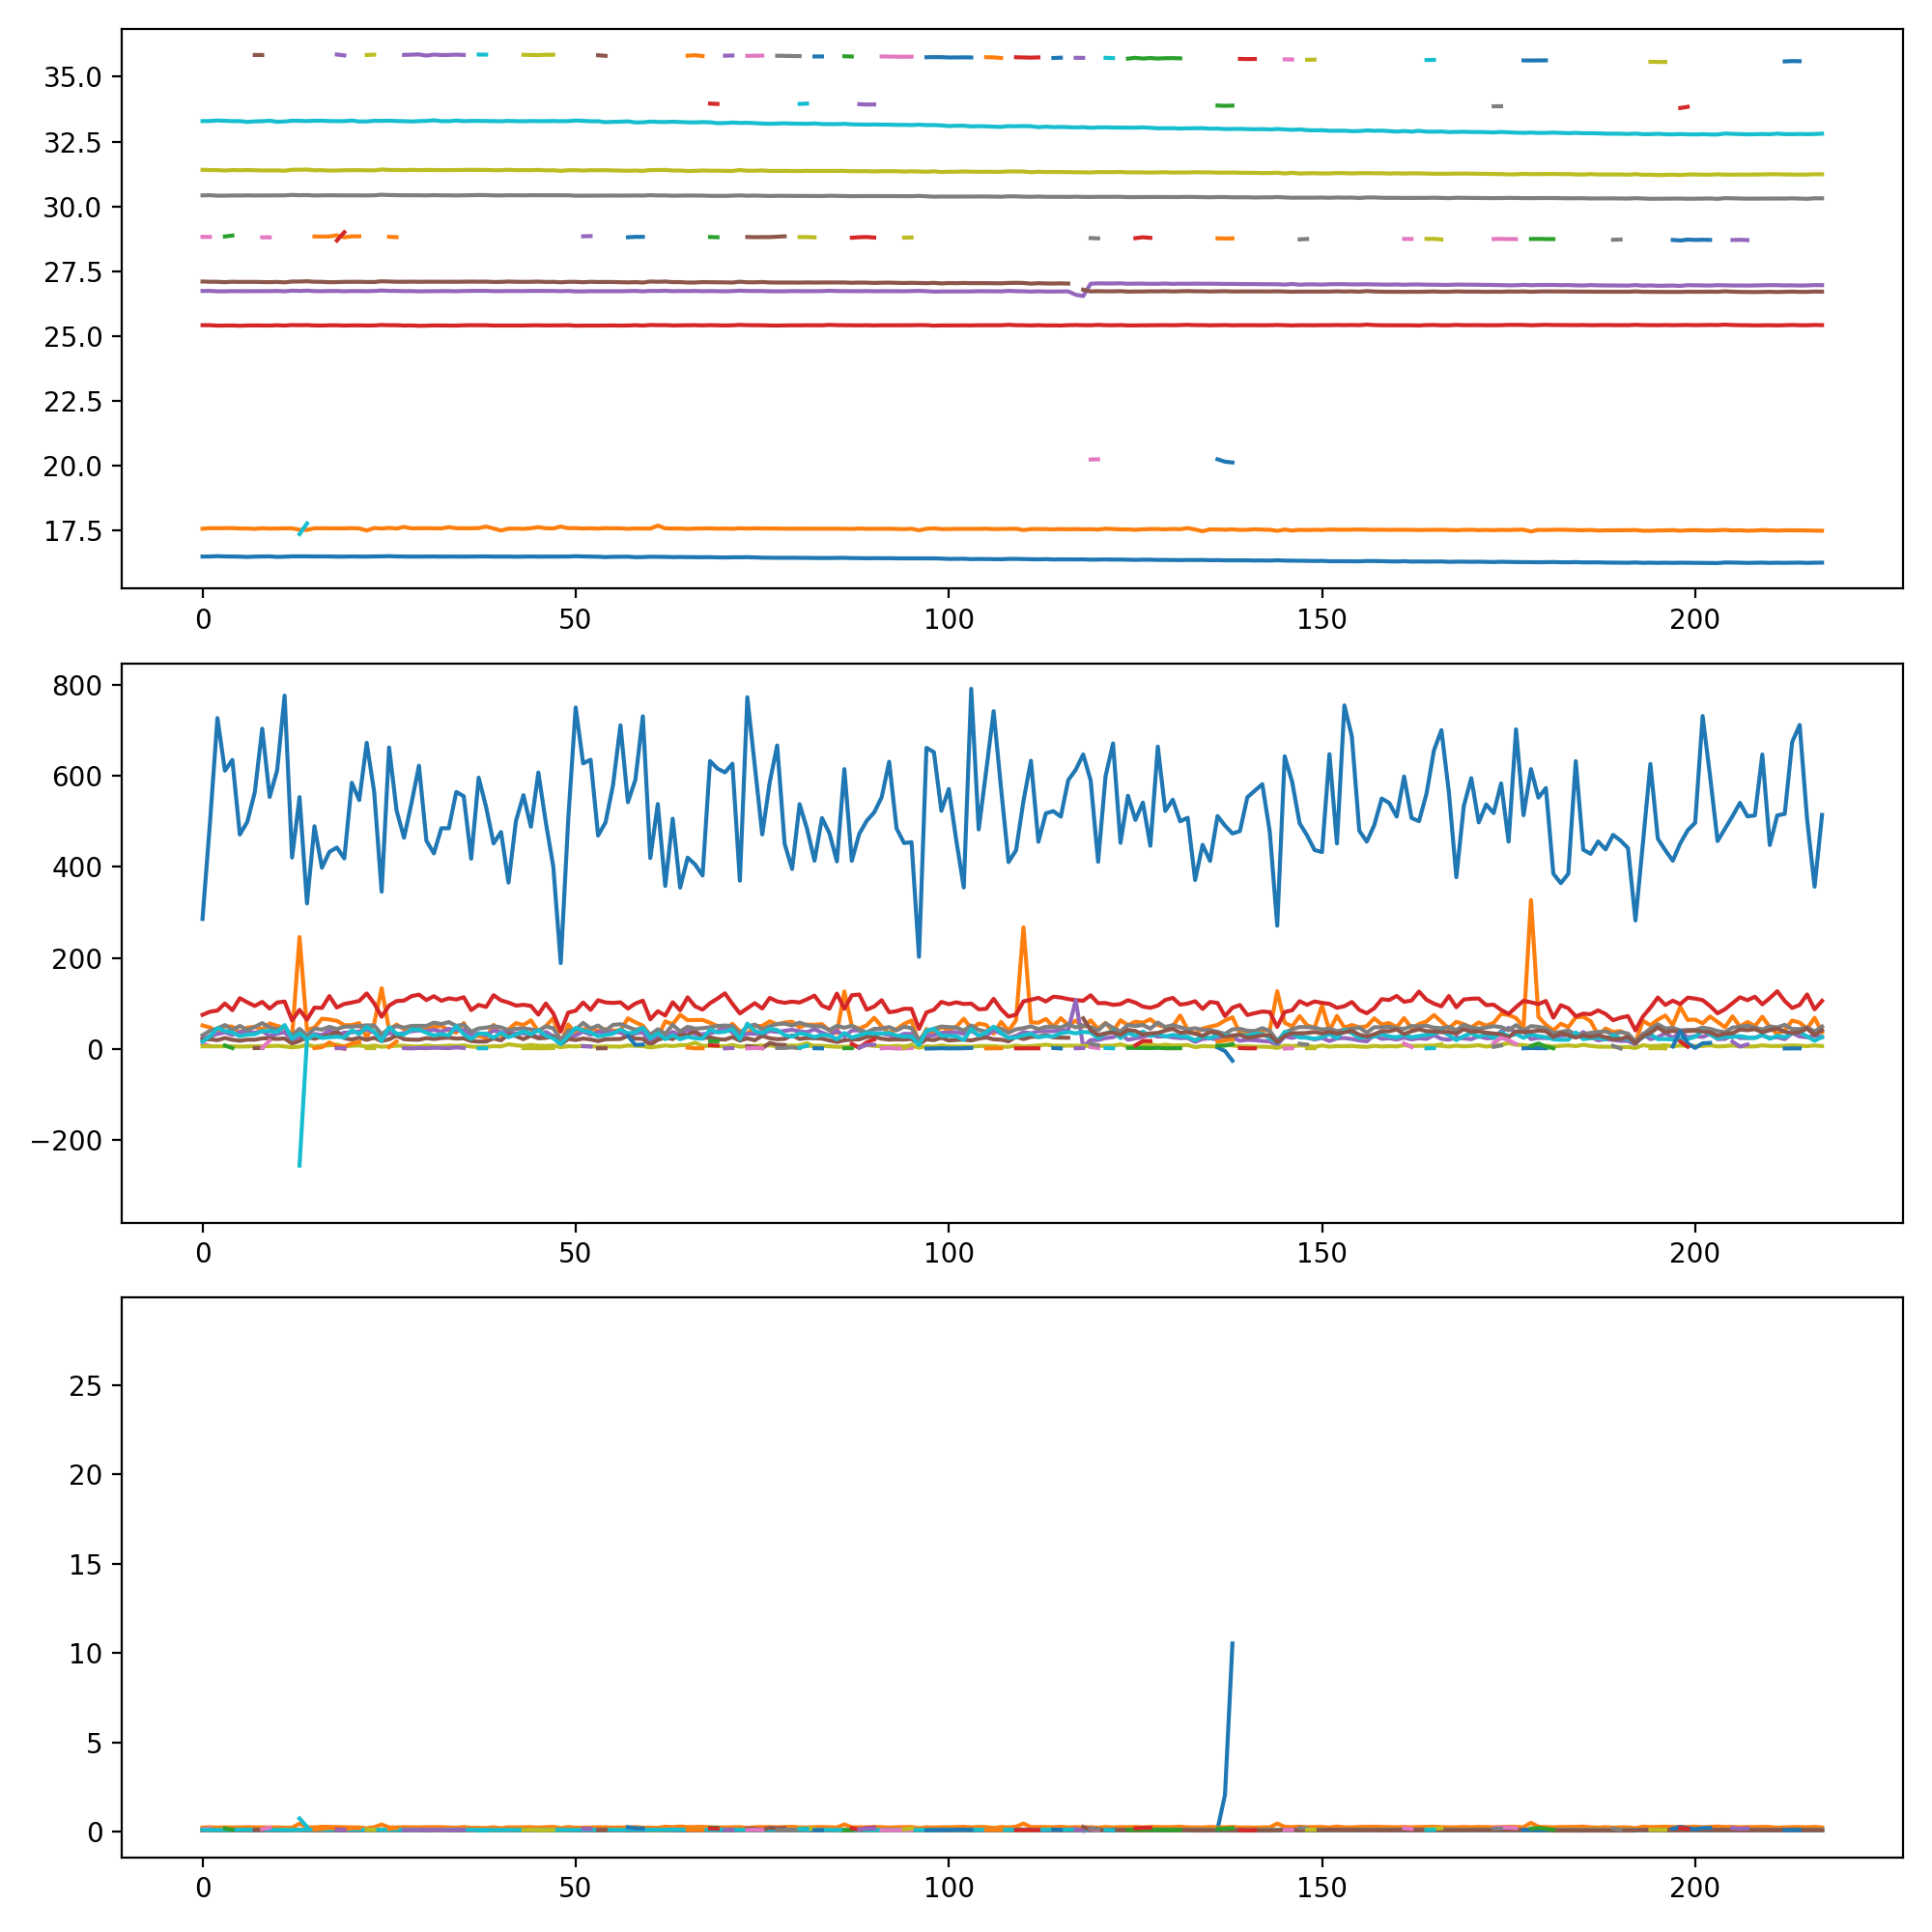

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize=(10,10), dpi=200, layout="tight")

x = np.arange(len(reflexes))
for ref in tracked_reflexes:
    ax1.plot(x, [reflexes[i][int(j),0] if not np.isnan(j) else np.nan for i, j in enumerate(ref)])
    ax2.plot(x, [reflexes[i][int(j),1] if not np.isnan(j) else np.nan for i, j in enumerate(ref)])
    ax3.plot(x, [reflexes[i][int(j),2] if not np.isnan(j) else np.nan for i, j in enumerate(ref)])

NameError: name 'reflexes' is not defined

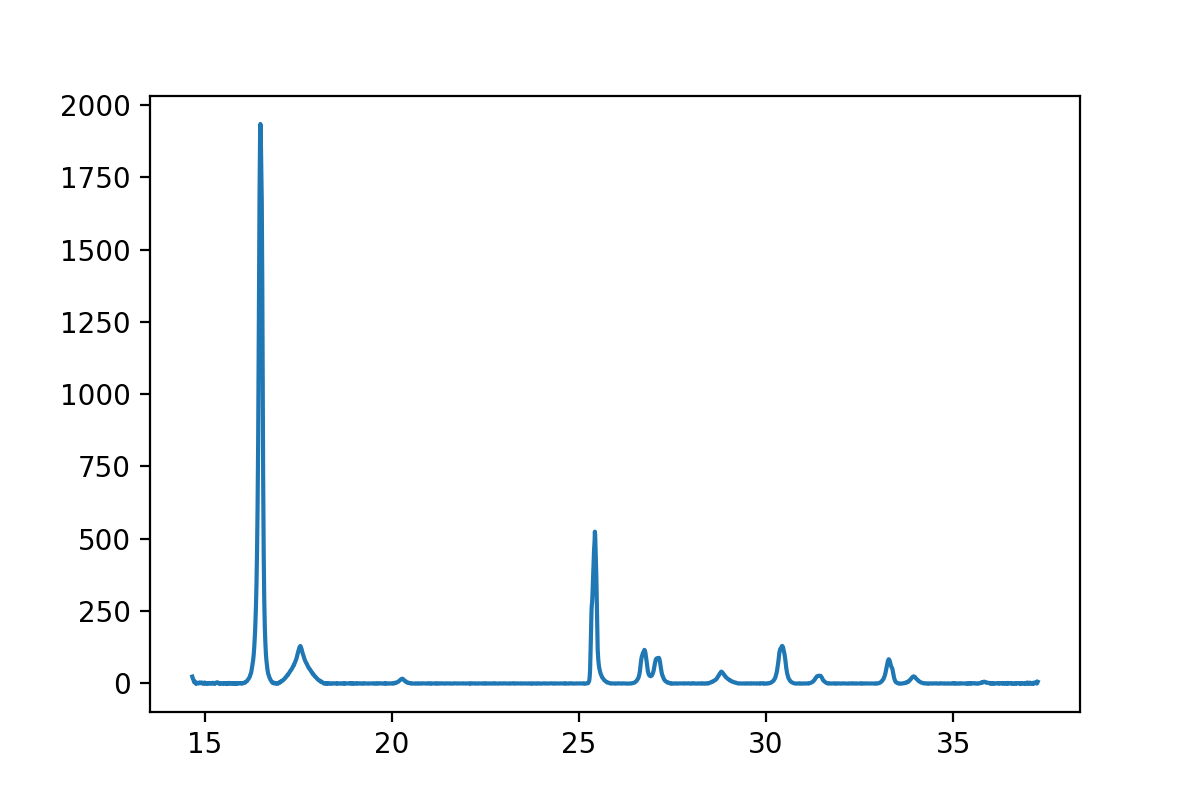

In [4]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider

def pseudo_voigt(x, A, mu, sigma, alpha):
    s_g = sigma/np.sqrt(2*np.log(2))
    return (1-alpha)*A/(s_g*np.sqrt(2*np.pi)) * np.exp(-np.square(x-mu)/(2*np.square(s_g))) + alpha*A/np.pi * (sigma/(np.square(x-mu)+np.square(sigma)))

idx0 = 0
x = XRD.data.twoTheta(13000)

plt.ion()
fig, ax = plt.subplots(figsize=(6,4), dpi = 200)
line_data = ax.plot(x, XRD.data.corrected[idx0])[0]
line_fit = ax.plot(x, np.vstack([pseudo_voigt(x, p[1], p[0], p[2], p[3]) for p in reflexes[idx0]]).sum(axis=0))[0]

slider = IntSlider(value=0, min=0, max=len(reflexes))

def update(val):
    idx = slider.value
    line_data.set_ydata(XRD.data.corrected[idx])
    line_fit.set_ydata(np.vstack([pseudo_voigt(x, p[1], p[0], p[2], p[3]) for p in reflexes[idx]]).sum(axis=0))
    fig.canvas.draw_idle()

slider.observe(update)
display(slider)


recalculating reflexes
6 finished
7 finished
3 finished
10 finished
8 finished
1 finished
2 finished
9 finished
0 finished
12 finished
13 finished
5 finished
14 finished
17 finished
4 finished
15 finished
24 finished
19 finished
25 finished
21 finished
26 finished
27 finished
23 finished
28 finished
11 finished
30 finished
33 finished
31 finished
32 finished
29 finished
35 finished
20 finished
18 finished
38 finished
36 finished
37 finished
41 finished
39 finished
43 finished
40 finished
45 finished
46 finished
50 finished
44 finished
49 finished
51 finished
22 finished
42 finished
54 finished
47 finished
53 finished
48 finished
58 finished
60 finished
56 finished
63 finished
64 finished
62 finished
66 finished
65 finished
57 finished
70 finished
71 finished
72 finished
73 finished
74 finished
75 finished
76 finished
77 finished
16 finished
68 finished
78 finished
81 finished
79 finished
80 finished
83 finished
85 finished
82 finished
67 finished
84 finished
87 finished
91 finished
88 

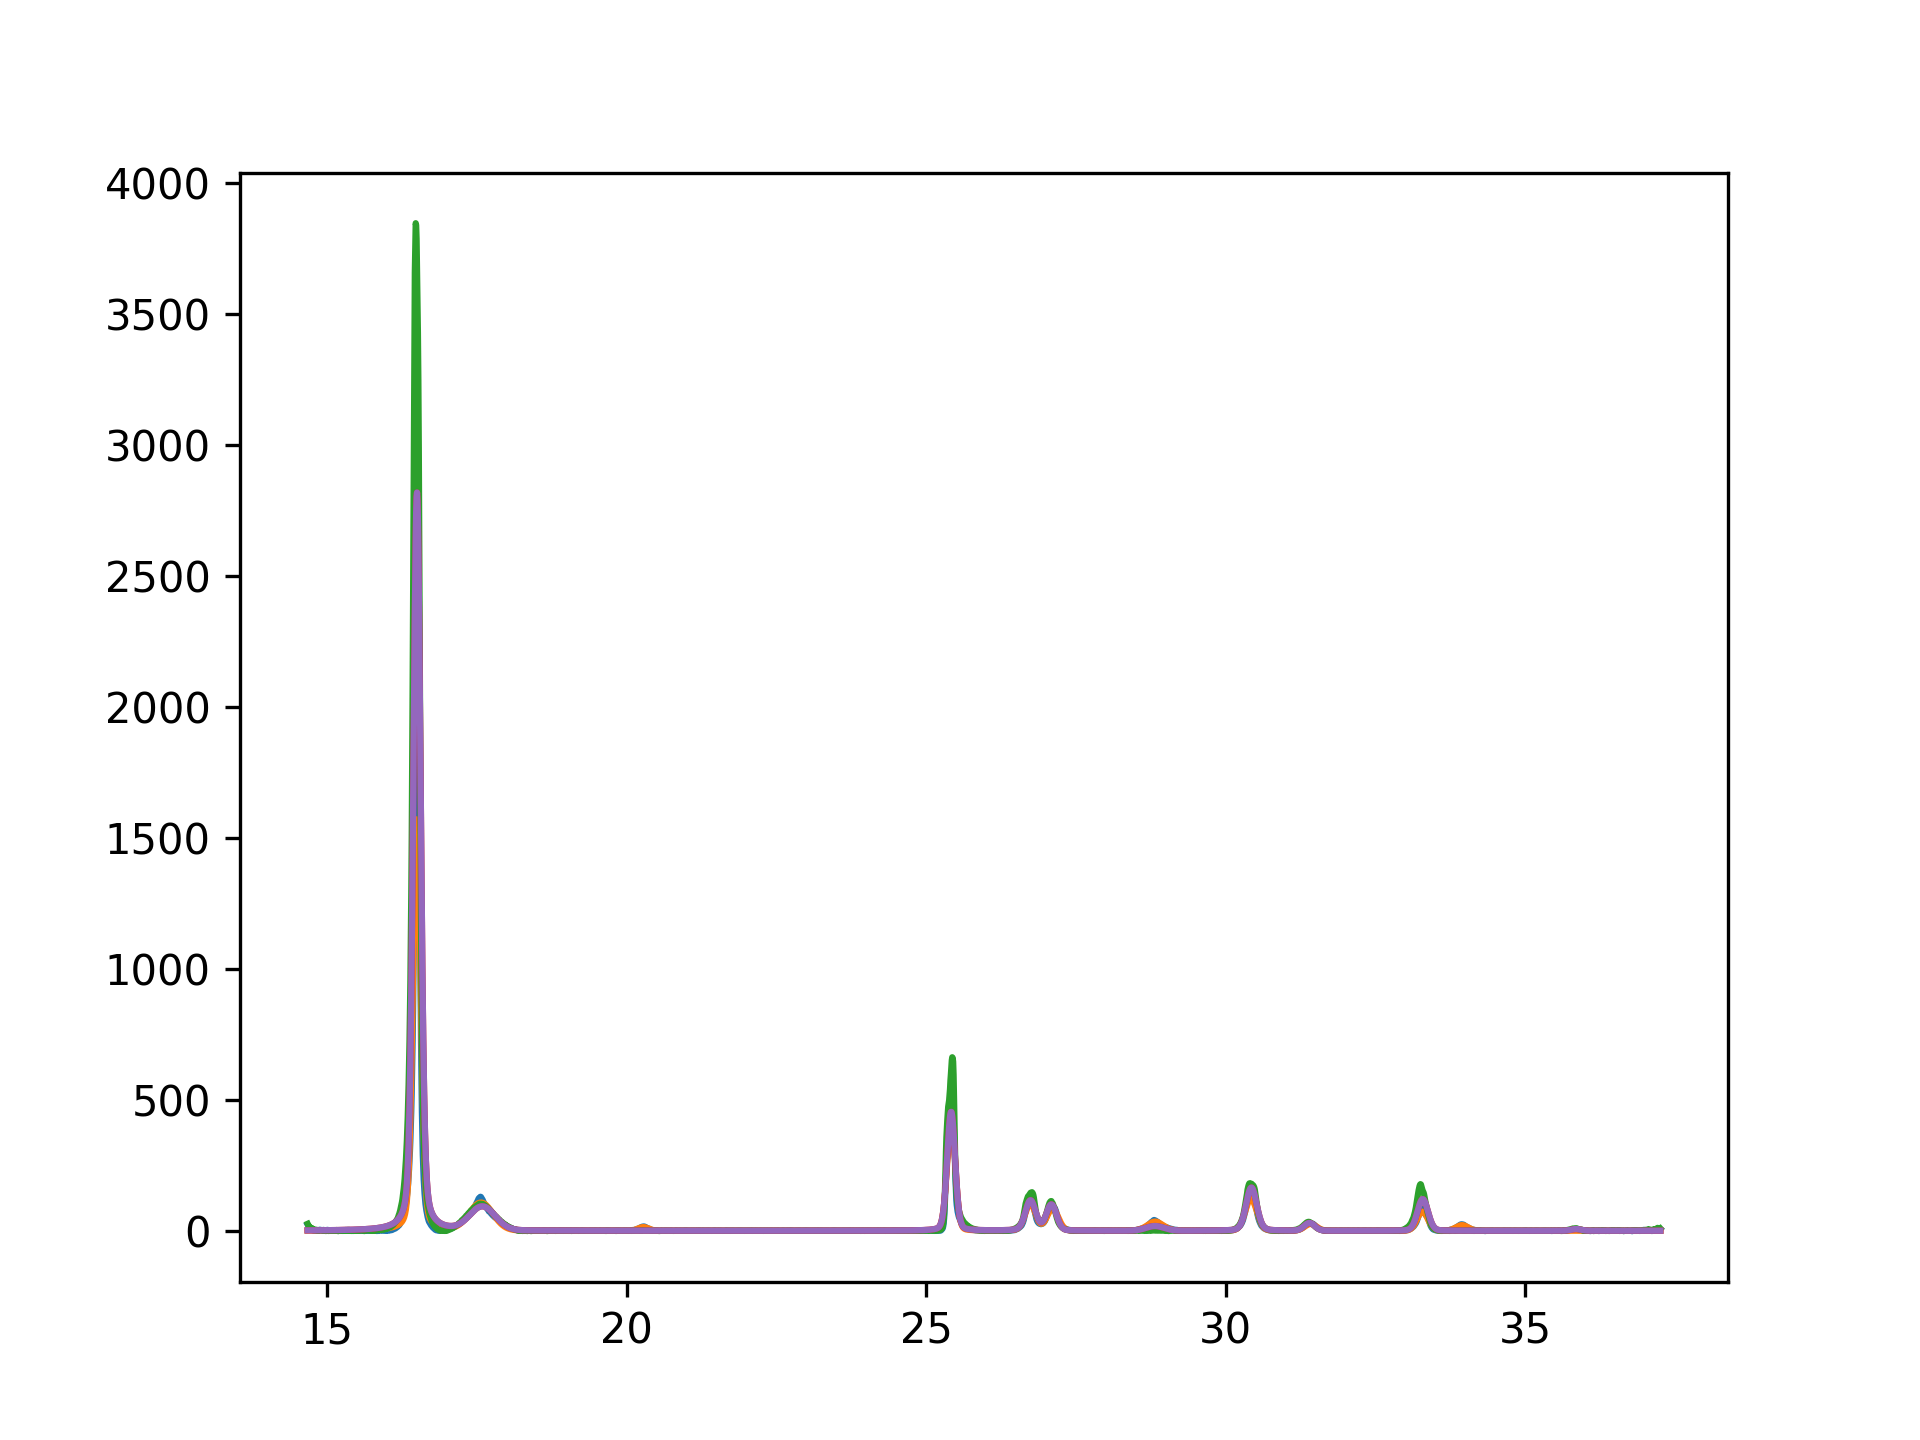

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def pseudo_voigt(x, A, mu, sigma, alpha):
    s_g = sigma/np.sqrt(2*np.log(2))
    return (1-alpha)*A/(s_g*np.sqrt(2*np.pi)) * np.exp(-np.square(x-mu)/(2*np.square(s_g))) + alpha*A/np.pi * (sigma/(np.square(x-mu)+np.square(sigma)))
plt.subplots(dpi=300)
x = XRD.data.twoTheta(13000)
plt.plot(x, XRD.data.corrected[0])
peaks = XRD.data.reflexes(13000)[0]
a = np.vstack([pseudo_voigt(x, p[1], p[0], p[2], p[3]) for p in peaks])
plt.plot(x, a.sum(axis=0))

plt.plot(x, XRD.data.corrected[10])
peaks = XRD.data.reflexes(13000)[1]
a = np.vstack([pseudo_voigt(x, p[1], p[0], p[2], p[3]) for p in peaks])
plt.plot(x, a.sum(axis=0))
# for r in peaks:
#     plt.axvline(r[0], ls="dotted")
print(a.shape)
plt.plot(x, a.sum(axis=0))